<div>
    <h1 id = "title"
        style = "background-color: #2788f9;
                 border-radius: 9px;
                 border-left:15px #1e3772 solid;
                 color: #f8f8f8;
                 line-height: 34px;
                 padding: 15px 0px 15px 20px; 
                 font-size: 28px;
                 font-weight: bold;
                 font-family: Trebuchet MS;">Chinese License Plate Recognition [YOLOv8 + CnOCR]
        <a class="anchor-link" id="title" href="chinese-license-plate-recognition-yolov8-cnocr#title">¶</a>
    </h1>
</div>

![Vehicle registration plates of China - Wikipedia](https://upload.wikimedia.org/wikipedia/commons/thumb/3/33/China_Fujian_Sanming_license_plate.jpg/1200px-China_Fujian_Sanming_license_plate.jpg)

<div>
    <h1 id = "preparation"
        style = "background-color: #9dd6fb;
                 border-radius: 15px;
                 border-left:15px #1e3772 solid;
                 color: #1e3772;
                 line-height: 26px;
                 padding: 12px; 
                 font-size: 24px;
                 font-weight: bold;
                 font-family: Trebuchet MS;">1. Preparation
        <a class="anchor-link" id="preparation" href="https://www.kaggle.com/code/harits/chinese-license-plate-recognition-yolov8-cnocr#preparation">¶</a>
    </h1>
</div>

In [1]:
# Import Libraries

# Warning
import warnings
warnings.filterwarnings("ignore")

# Main
import os
import gc
import shutil
import time
import random
import cv2
import numpy as np 
import pandas as pd
import glob
from tqdm import tqdm
tqdm.pandas()
import re

# Data Visualization
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import plotly
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from IPython.display import Image, display

import torch
from numba import cuda

In [2]:
provinces = ["皖", "沪", "津", "渝", "冀", "晋", "蒙", "辽", "吉", "黑", "苏", "浙", "京", "闽", "赣", "鲁", "豫", "鄂", "湘", "粤", "桂", "琼", "川", "贵", "云", "藏", "陕", "甘", "青", "宁", "新", "警", "学", "O"]
alphabets = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'J', 'K', 'L', 'M', 'N', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W',
             'X', 'Y', 'Z', 'O']
ads = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'J', 'K', 'L', 'M', 'N', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X',
       'Y', 'Z', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'O']

list_sub = ["ccpd_base", "ccpd_fn", "ccpd_db", "ccpd_rotate", "ccpd_weather", "ccpd_blur"]
BASE_PATH = "/kaggle/input/chinese-city-parking-dataset-eccv/CCPD2019/"

<div class="alert alert-block alert-info" style="color: black; font-size: 15px; font-family: Trebuchet MS">
    <b>Sub Datasets</b>:
    <ul>
        <li><b>CCPD-Base</b>: The only common feature of these photos is the inclusion of a license plate</li>
        <li><b>CCPD-FN</b>: The distance from the LP to the shooting location is relatively far or near</li>
        <li><b>CCPD-DB</b>: Illuminations on the LP area are dark, uneven or extremely bright</li>
        <li><b>CCPD-Rotate</b>: Great horizontal tilt degree (20◦
 50◦) and the vertical tilt degree varies from -10◦ to 10</li>
        <li><b>CCPD-Weather</b>: Images taken on a rainy day, snow day or fog day</li>
        <li><b>CCPD-Blur</b>: Blurry largely due to hand jitter while taking pictures</li>
    </ul>
</div>

<div>
    <h1 id = "data-exploration"
        style = "background-color: #9dd6fb;
                 border-radius: 15px;
                 border-left:15px #1e3772 solid;
                 color: #1e3772;
                 line-height: 26px;
                 padding: 12px; 
                 font-size: 24px;
                 font-weight: bold;
                 font-family: Trebuchet MS;">2. Data Exploration
        <a class="anchor-link" id="data-exploration" href="https://www.kaggle.com/code/harits/chinese-license-plate-recognition-yolov8-cnocr#data-exploration">¶</a>
    </h1>
</div>

<div>
    <h2 id = "sample-images"
        style = "background-color: #9dd6fb;
                 border-radius: 15px;
                 color: #1e3772;
                 line-height: 20px;
                 padding: 11px; 
                 font-size: 20px;
                 font-weight: bold;
                 font-family: Trebuchet MS;">2.1. Sample Images
    </h2>
</div>

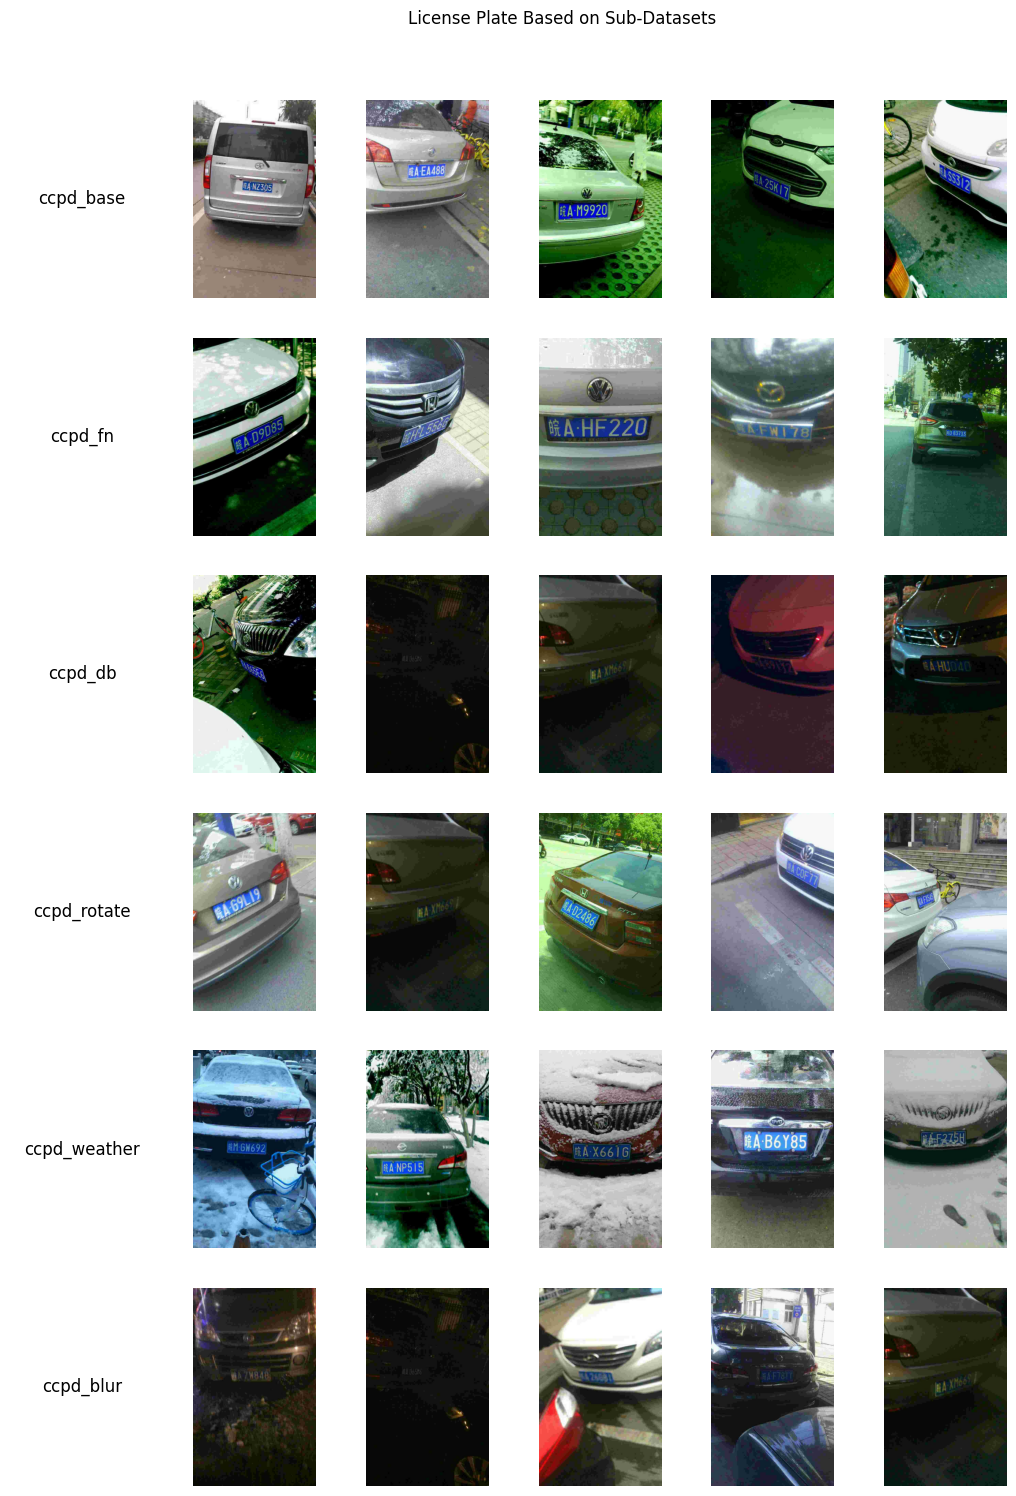

In [3]:
# Sample Images

# Create Subplots
fig, axs = plt.subplots(6, 6, figsize=(13, 18))

# Plot the Data
for i, sub in enumerate(list_sub):    
    axs[i, 0].text(0.5, 0.5, sub, ha='center', va='center', fontsize=12)
    axs[i, 0].axis('off')
    
    sub_path = os.path.join(BASE_PATH, sub)
    sub_files = os.listdir(sub_path)[:5]
    
    for j in range(5):
        file_name = os.path.join(sub_path, sub_files[j])
        image = cv2.imread(file_name)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        axs[i, j+1].imshow(image)
        axs[i, j+1].axis("off")

# Title
plt.suptitle("License Plate Based on Sub-Datasets", x=0.55, y=0.93)

# Show
plt.show()

<div>
    <h2 id = "image-description"
        style = "background-color: #9dd6fb;
                 border-radius: 15px;
                 color: #1e3772;
                 line-height: 20px;
                 padding: 11px; 
                 font-size: 20px;
                 font-weight: bold;
                 font-family: Trebuchet MS;">2.2. Image Description
    </h2>
</div>

File Name: /kaggle/input/chinese-city-parking-dataset-eccv/CCPD2019/ccpd_base/0148180076628-93_92-273&472_484&547-465&548_288&530_295&469_472&487-0_0_12_23_27_24_29-100-44.jpg
Area Ratio: 0148180076628
Tilt Degrees
-  Horizontal: 93
-  Vertical  : 92
Bounding Box
-  Left-Up     : 273&472
-  Right-Bottom: 484&547
Vertices
-  Right-Bottom: 465&548
-  Left-Bottom : 288&530
-  Left-Up     : 295&469
-  Right-Up    : 472&487
License Plate Number: 皖A NZ305
Brightness: 100
Blurriness: 44


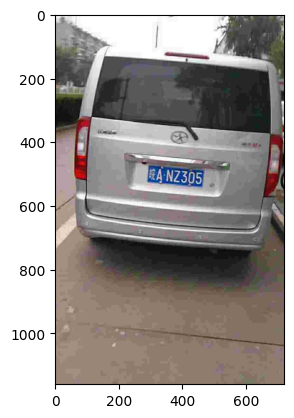

File Name: /kaggle/input/chinese-city-parking-dataset-eccv/CCPD2019/ccpd_base/0171312260536-90_93-253&375_469&462-470&451_250&463_255&378_475&366-0_0_4_0_28_32_32-142-24.jpg
Area Ratio: 0171312260536
Tilt Degrees
-  Horizontal: 90
-  Vertical  : 93
Bounding Box
-  Left-Up     : 253&375
-  Right-Bottom: 469&462
Vertices
-  Right-Bottom: 470&451
-  Left-Bottom : 250&463
-  Left-Up     : 255&378
-  Right-Up    : 475&366
License Plate Number: 皖A EA488
Brightness: 142
Blurriness: 24


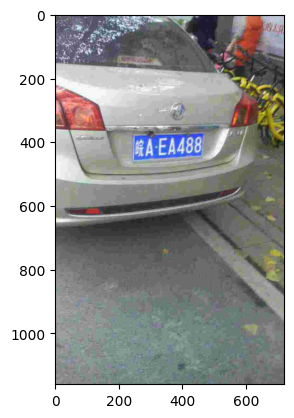

File Name: /kaggle/input/chinese-city-parking-dataset-eccv/CCPD2019/ccpd_base/0311733716476-89_90-111&598_422&709-412&694_122&704_129&598_419&588-0_0_11_33_33_26_24-68-159.jpg
Area Ratio: 0311733716476
Tilt Degrees
-  Horizontal: 89
-  Vertical  : 90
Bounding Box
-  Left-Up     : 111&598
-  Right-Bottom: 422&709
Vertices
-  Right-Bottom: 412&694
-  Left-Bottom : 122&704
-  Left-Up     : 129&598
-  Right-Up    : 419&588
License Plate Number: 皖A M9920
Brightness: 68
Blurriness: 159


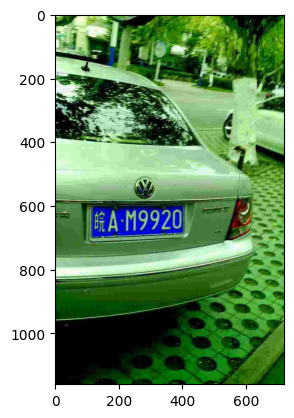

In [4]:
# Image Description
ccpd_base_path = os.path.join(BASE_PATH, "ccpd_base")
ccpd_base_files = os.listdir(ccpd_base_path)
for file in ccpd_base_files[:3]:
    # File Name
    file_name = os.path.join(ccpd_base_path, file)
    file_splitting = file_name.split("/")[-1][:-4]
    file_splitting = file_splitting.split("-")
    print("File Name:", file_name)
    
    # Area Ratio
    area_ratio = file_splitting[0]
    print("Area Ratio:", area_ratio)
    
    # Tilt Degrees
    tilt_degrees = file_splitting[1]
    hor_tilt_degrees = tilt_degrees.split("_")[0]
    ver_tilt_degrees = tilt_degrees.split("_")[1]
    print("Tilt Degrees")
    print("-  Horizontal:", hor_tilt_degrees)
    print("-  Vertical  :", ver_tilt_degrees)
    
    # Bounding Box
    bounding_box = file_splitting[2]
    left_up_bbox = bounding_box.split("_")[0]
    right_bot_bbox = bounding_box.split("_")[1]
    print("Bounding Box")
    print("-  Left-Up     :", left_up_bbox)
    print("-  Right-Bottom:", right_bot_bbox)
    
    # Exact Vertices
    vertices = file_splitting[3]
    right_bot_vtc = vertices.split("_")[0]
    left_bot_vtc = vertices.split("_")[1]
    left_up_vtc = vertices.split("_")[2]
    right_up_vtc = vertices.split("_")[3]
    print("Vertices")
    print("-  Right-Bottom:", right_bot_vtc)
    print("-  Left-Bottom :", left_bot_vtc)
    print("-  Left-Up     :", left_up_vtc)
    print("-  Right-Up    :", right_up_vtc)
    
    # License Plate Numbers
    lcn = file_splitting[4]
    chi_let = provinces[int(lcn.split("_")[0])]
    alp_let = alphabets[int(lcn.split("_")[1])]
    alp_num_let = lcn.split("_")[2:]
    alp_num_let = "".join([ads[int(char)] for char in alp_num_let])
    all_let = chi_let + alp_let + " " + alp_num_let
    print("License Plate Number:", all_let)
    
    # Brightness
    brightness = file_splitting[5]
    print("Brightness:", brightness)
    
    # Blurriness
    blurriness = file_splitting[6]
    print("Blurriness:", blurriness)
    
    img = cv2.imread(file_name)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(img)
    plt.show()

<div>
    <h2 id = "bbox-and-lpr"
        style = "background-color: #9dd6fb;
                 border-radius: 15px;
                 color: #1e3772;
                 line-height: 20px;
                 padding: 11px; 
                 font-size: 20px;
                 font-weight: bold;
                 font-family: Trebuchet MS;">2.3. Sample Bounding Box and Exact Vertices
    </h2>
</div>

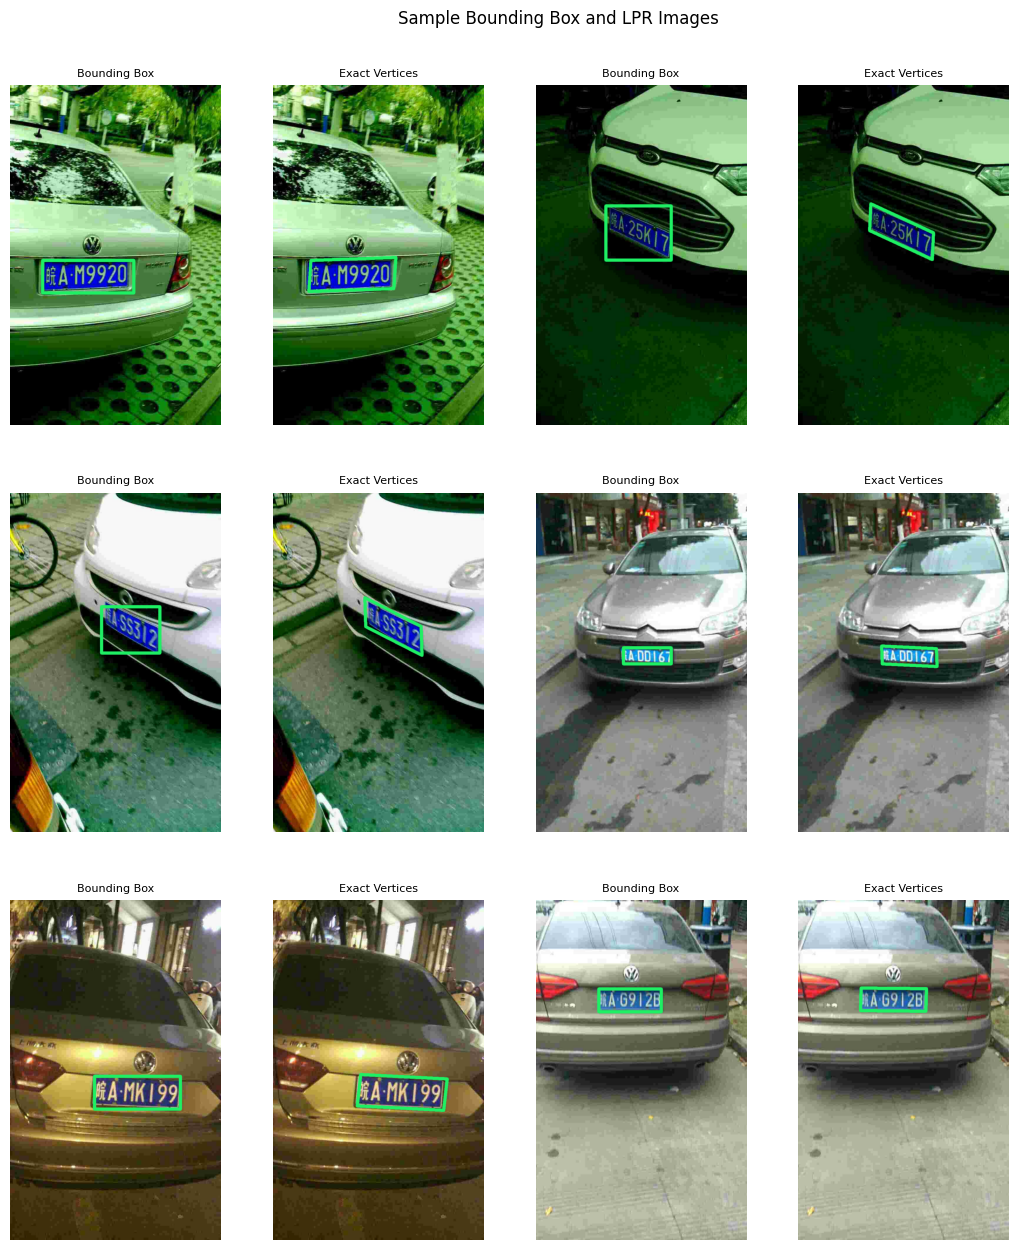

In [5]:
# Sample Bounding Box and Exact Vertices

# Create Subplots
fig, axs = plt.subplots(3, 4, figsize=(13, 15))

# Plot the Data
for i, file in enumerate(ccpd_base_files[2:8]):
    # File Name
    file_name = os.path.join(ccpd_base_path, file)
    file_splitting = file_name.split("/")[-1][:-4]
    file_splitting = file_splitting.split("-")
    
    # License Plate Numbers
    lcn = file_splitting[4]
    chi_let = provinces[int(lcn.split("_")[0])]
    alp_let = alphabets[int(lcn.split("_")[1])]
    alp_num_let = lcn.split("_")[2:]
    alp_num_let = "".join([ads[int(char)] for char in alp_num_let])
    all_let = chi_let + alp_let + alp_num_let
    
    # Bounding Box
    bounding_box = file_splitting[2]
    lu_bbox = bounding_box.split("_")[0]
    x1, y1 = list(map(int, lu_bbox.split("&")))
    rb_bbox = bounding_box.split("_")[1]
    x2, y2 = list(map(int, rb_bbox.split("&")))
    
    bbox_img = cv2.imread(file_name)
    bbox_img = cv2.cvtColor(bbox_img, cv2.COLOR_BGR2RGB)
    cv2.rectangle(bbox_img, (x1, y1), (x2, y2), (30, 240, 100), 10)
#     cv2.rectangle(bbox_img, (x1-50, y1-90), (x2+50, y1), (30, 240, 100), -1, 10)
    
#     # Add License Plate Number
#     textsize = cv2.getTextSize(all_let, cv2.FONT_HERSHEY_SIMPLEX, 1.5, 4)[0]
#     textX = ((x2-x1+100) - textsize[0]) // 2
#     textY = (90 + textsize[1]) // 2
    
#     cv2.putText(bbox_img, all_let, (textX+x1-50, textY+y1-90), cv2.FONT_HERSHEY_SIMPLEX, 1.5, (0,0,0), 4)
    
    axs[i//2, (i*2)%4].imshow(bbox_img)
    axs[i//2, (i*2)%4].set_title("Bounding Box", fontsize=8)
    axs[i//2, (i*2)%4].axis("off")
    axs[i//2, (i*2)%4]
    
    # Exact Vertices
    vertices = file_splitting[3]
    vertices_split = vertices.split("_")
    
    exver_img = cv2.imread(file_name)
    exver_img = cv2.cvtColor(exver_img, cv2.COLOR_BGR2RGB)
    for j in range(4):
        x1, y1 = list(map(int, vertices_split[j].split("&")))
        x2, y2 = list(map(int, vertices_split[(j+1)%4].split("&")))
        cv2.line(exver_img, (x1, y1), (x2, y2), (30, 240, 100), thickness=10)
        
    axs[i//2, (i*2+1)%4].imshow(exver_img)
    axs[i//2, (i*2+1)%4].set_title("Exact Vertices", fontsize=8)
    axs[i//2, (i*2+1)%4].axis("off")
    axs[i//2, (i*2+1)%4]

# Title
plt.suptitle("Sample Bounding Box and LPR Images", x=0.55, y=0.93)

# Show
plt.show()

<div>
    <h1 id = "plate-detection"
        style = "background-color: #9dd6fb;
                 border-radius: 15px;
                 border-left:15px #1e3772 solid;
                 color: #1e3772;
                 line-height: 26px;
                 padding: 12px; 
                 font-size: 24px;
                 font-weight: bold;
                 font-family: Trebuchet MS;">3. Plate Detection - YOLOv8
        <a class="anchor-link" id="plate-detection" href="https://www.kaggle.com/code/harits/chinese-license-plate-recognition-yolov8-cnocr#plate-detection">¶</a>
    </h1>
</div>

<div>
    <h2 id = "data-preparation"
        style = "background-color: #9dd6fb;
                 border-radius: 15px;
                 color: #1e3772;
                 line-height: 20px;
                 padding: 11px; 
                 font-size: 20px;
                 font-weight: bold;
                 font-family: Trebuchet MS;">3.1. Data Preparation
    </h2>
</div>

<div>
    <h3 style = "color: #2788f9; font-size: 18px; font-family: Trebuchet MS; font-weight: bold;">Create Metadata</h3>
</div>

In [6]:
# Create Metadata
def extract_plate_number(plate_number):
    chi_let = provinces[int(plate_number.split("_")[0])]
    alp_let = alphabets[int(plate_number.split("_")[1])]
    alp_num_let = plate_number.split("_")[2:]
    alp_num_let = "".join([ads[int(char)] for char in alp_num_let])
    all_let = chi_let + alp_let + alp_num_let
    return all_let

df_metadata = pd.DataFrame()
for sub in list_sub:
    sub_path = os.path.join(BASE_PATH, sub, "*")
    sub_files = glob.glob(sub_path)
    
    df_metadata = df_metadata.append(sub_files)

df_metadata = df_metadata.rename(columns={0: "image_path"}).reset_index(drop=True)
df_metadata["sub"] = df_metadata["image_path"].apply(lambda x: x.split("/")[5])
df_metadata["detail"] = df_metadata["image_path"].apply(lambda x: x.split("/")[6])
df_metadata["bbox"] = df_metadata["detail"].apply(lambda x: x.split("-")[2])
df_metadata["x1_bbox"] = df_metadata["bbox"].apply(lambda x: int(x.split("_")[0].split("&")[0]))
df_metadata["y1_bbox"] = df_metadata["bbox"].apply(lambda x: int(x.split("_")[0].split("&")[1]))
df_metadata["x2_bbox"] = df_metadata["bbox"].apply(lambda x: int(x.split("_")[1].split("&")[0]))
df_metadata["y2_bbox"] = df_metadata["bbox"].apply(lambda x: int(x.split("_")[1].split("&")[1]))
df_metadata["plate_number"] = df_metadata["detail"].apply(lambda x: x.split("-")[4])
df_metadata["plate_number"] = df_metadata["plate_number"].apply(lambda x: extract_plate_number(x))

df_metadata = df_metadata.drop(["detail", "bbox"], axis=1)
df_metadata

,image_path,sub,x1_bbox,y1_bbox,x2_bbox,y2_bbox,plate_number
0,/kaggle/input/chinese-city-parking-dataset-ecc...,ccpd_base,273,472,484,547,皖ANZ305
1,/kaggle/input/chinese-city-parking-dataset-ecc...,ccpd_base,253,375,469,462,皖AEA488
2,/kaggle/input/chinese-city-parking-dataset-ecc...,ccpd_base,111,598,422,709,皖AM9920
3,/kaggle/input/chinese-city-parking-dataset-ecc...,ccpd_base,238,412,461,597,皖A25K17
4,/kaggle/input/chinese-city-parking-dataset-ecc...,ccpd_base,312,391,511,549,皖ASS312
...,...,...,...,...,...,...,...
5495,/kaggle/input/chinese-city-parking-dataset-ecc...,ccpd_blur,356,445,470,485,皖AR7592
5496,/kaggle/input/chinese-city-parking-dataset-ecc...,ccpd_blur,347,332,465,376,皖AN906J
5497,/kaggle/input/chinese-city-parking-dataset-ecc...,ccpd_blur,256,482,508,597,皖A187L8
5498,/kaggle/input/chinese-city-parking-dataset-ecc...,ccpd_blur,217,481,396,584,皖A7U770


<div>
    <h3 style = "color: #2788f9; font-size: 18px; font-family: Trebuchet MS; font-weight: bold;">Create YOLOv8 Bounding Box Format</h3>
</div>

In [7]:
df_metadata['xmid'] = (df_metadata['x1_bbox'] + df_metadata['x2_bbox']) / (2*720)
df_metadata['ymid'] = (df_metadata['y1_bbox'] + df_metadata['y2_bbox']) / (2*1160)

df_metadata['bb_width'] = (df_metadata['x2_bbox'] - df_metadata['x1_bbox']) / 720
df_metadata['bb_height'] = (df_metadata['y2_bbox'] - df_metadata['y1_bbox']) / 1160

df_metadata

,image_path,sub,x1_bbox,y1_bbox,x2_bbox,y2_bbox,plate_number,xmid,ymid,bb_width,bb_height
0,/kaggle/input/chinese-city-parking-dataset-ecc...,ccpd_base,273,472,484,547,皖ANZ305,0.525694,0.439224,0.293056,0.064655
1,/kaggle/input/chinese-city-parking-dataset-ecc...,ccpd_base,253,375,469,462,皖AEA488,0.501389,0.360776,0.300000,0.075000
2,/kaggle/input/chinese-city-parking-dataset-ecc...,ccpd_base,111,598,422,709,皖AM9920,0.370139,0.563362,0.431944,0.095690
3,/kaggle/input/chinese-city-parking-dataset-ecc...,ccpd_base,238,412,461,597,皖A25K17,0.485417,0.434914,0.309722,0.159483
4,/kaggle/input/chinese-city-parking-dataset-ecc...,ccpd_base,312,391,511,549,皖ASS312,0.571528,0.405172,0.276389,0.136207
...,...,...,...,...,...,...,...,...,...,...,...
5495,/kaggle/input/chinese-city-parking-dataset-ecc...,ccpd_blur,356,445,470,485,皖AR7592,0.573611,0.400862,0.158333,0.034483
5496,/kaggle/input/chinese-city-parking-dataset-ecc...,ccpd_blur,347,332,465,376,皖AN906J,0.563889,0.305172,0.163889,0.037931
5497,/kaggle/input/chinese-city-parking-dataset-ecc...,ccpd_blur,256,482,508,597,皖A187L8,0.530556,0.465086,0.350000,0.099138
5498,/kaggle/input/chinese-city-parking-dataset-ecc...,ccpd_blur,217,481,396,584,皖A7U770,0.425694,0.459052,0.248611,0.088793


<div>
    <h3 style = "color: #2788f9; font-size: 18px; font-family: Trebuchet MS; font-weight: bold;">Data Splitting</h3>
</div>

In [8]:
# Train : 5000 (ccpd_base), Val and Test : 50 for each sub (except ccpd_base)
list_split = ["train"] * 5000
for i in range(5):
    list_split.extend(["val"]*50)
    list_split.extend(["test"]*50)
df_metadata["split"] = list_split
df_metadata

,image_path,sub,x1_bbox,y1_bbox,x2_bbox,y2_bbox,plate_number,xmid,ymid,bb_width,bb_height,split
0,/kaggle/input/chinese-city-parking-dataset-ecc...,ccpd_base,273,472,484,547,皖ANZ305,0.525694,0.439224,0.293056,0.064655,train
1,/kaggle/input/chinese-city-parking-dataset-ecc...,ccpd_base,253,375,469,462,皖AEA488,0.501389,0.360776,0.300000,0.075000,train
2,/kaggle/input/chinese-city-parking-dataset-ecc...,ccpd_base,111,598,422,709,皖AM9920,0.370139,0.563362,0.431944,0.095690,train
3,/kaggle/input/chinese-city-parking-dataset-ecc...,ccpd_base,238,412,461,597,皖A25K17,0.485417,0.434914,0.309722,0.159483,train
4,/kaggle/input/chinese-city-parking-dataset-ecc...,ccpd_base,312,391,511,549,皖ASS312,0.571528,0.405172,0.276389,0.136207,train
...,...,...,...,...,...,...,...,...,...,...,...,...
5495,/kaggle/input/chinese-city-parking-dataset-ecc...,ccpd_blur,356,445,470,485,皖AR7592,0.573611,0.400862,0.158333,0.034483,test
5496,/kaggle/input/chinese-city-parking-dataset-ecc...,ccpd_blur,347,332,465,376,皖AN906J,0.563889,0.305172,0.163889,0.037931,test
5497,/kaggle/input/chinese-city-parking-dataset-ecc...,ccpd_blur,256,482,508,597,皖A187L8,0.530556,0.465086,0.350000,0.099138,test
5498,/kaggle/input/chinese-city-parking-dataset-ecc...,ccpd_blur,217,481,396,584,皖A7U770,0.425694,0.459052,0.248611,0.088793,test


<div>
    <h2 id = "yolo-preparation"
        style = "background-color: #9dd6fb;
                 border-radius: 15px;
                 color: #1e3772;
                 line-height: 20px;
                 padding: 11px; 
                 font-size: 20px;
                 font-weight: bold;
                 font-family: Trebuchet MS;">3.2. YOLOv8 Preparation
    </h2>
</div>

In [9]:
!git clone https://github.com/ultralytics/ultralytics
!pip install ultralytics

Cloning into 'ultralytics'...
remote: Enumerating objects: 8118, done.
remote: Counting objects: 100% (231/231), done.
remote: Compressing objects: 100% (143/143), done.
remote: Total 8118 (delta 125), reused 173 (delta 88), pack-reused 7887
Receiving objects: 100% (8118/8118), 5.84 MiB | 19.36 MiB/s, done.
Resolving deltas: 100% (5456/5456), done.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 585.2/585.2 kB 15.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.8/61.8 MB 18.6 MB/s eta 0:00:00
  Attempting uninstall: opencv-python
    Found existing installation: opencv-python 4.5.4.60
    Uninstalling opencv-python-4.5.4.60:
      Successfully uninstalled opencv-python-4.5.4.60


In [10]:
# Create Dataset Folder in YOLOv8
!mkdir "/kaggle/working/ultralytics/datasets"
!mkdir "/kaggle/working/ultralytics/datasets/train"
!mkdir "/kaggle/working/ultralytics/datasets/val"
!mkdir "/kaggle/working/ultralytics/datasets/test"

In [11]:
# https://www.kaggle.com/code/aslanahmedov/automatic-number-plate-recognition/notebook
# Copy Image to YOLOv8 Dataset Folder and Create Text
def image_and_text_yolo(split):
    df = df_metadata[df_metadata["split"]==split].reset_index(drop=True)
    folder_path = os.path.join("/kaggle/working/ultralytics/datasets", split)
    
    values = df[['image_path','xmid','ymid','bb_width','bb_height']].values
    for file_name, x, y, w, h in values:
        image_name = os.path.split(file_name)[-1]
        txt_name = os.path.splitext(image_name)[0]

        dst_image_path = os.path.join(folder_path, image_name)
        dst_label_file = os.path.join(folder_path, txt_name+'.txt')

        # copy each image into the folder
        shutil.copy(file_name, dst_image_path)

        # generate .txt which has label info
        label_txt = f'0 {x} {y} {w} {h}'
        with open(dst_label_file, mode='w') as f:
            f.write(label_txt)
            f.close()
            
image_and_text_yolo("train")
print("Train Dataset Created")
image_and_text_yolo("val")
print("Val Dataset Created")
image_and_text_yolo("test")
print("Test Dataset Created")

Train Dataset Created
Val Dataset Created
Test Dataset Created


In [12]:
%%writefile /kaggle/working/ultralytics/custom_dataset.yaml
# Create Custom Dataset Configuration
train: /kaggle/working/ultralytics/datasets/train
val: /kaggle/working/ultralytics/datasets/val
test: /kaggle/working/ultralytics/datasets/test
    
nc: 1
    
names: [
    'license_plate'
]

Writing /kaggle/working/ultralytics/custom_dataset.yaml


<div>
    <h2 id = "yolo-training"
        style = "background-color: #9dd6fb;
                 border-radius: 15px;
                 color: #1e3772;
                 line-height: 20px;
                 padding: 11px; 
                 font-size: 20px;
                 font-weight: bold;
                 font-family: Trebuchet MS;">3.3. YOLOv8 Training
    </h2>
</div>

In [13]:
!pip install GPUtil
from GPUtil import showUtilization as gpu_usage

def free_gpu_cache():
    print("Initial GPU Usage")
    gpu_usage()                             

    torch.cuda.empty_cache()

    cuda.select_device(0)
    cuda.close()
    cuda.select_device(0)

    print("GPU Usage after emptying the cache")
    gpu_usage()

free_gpu_cache()

  Preparing metadata (setup.py) ... - \ done
  Created wheel for GPUtil: filename=GPUtil-1.4.0-py3-none-any.whl size=7409 sha256=9d5561237c58577ee9567dbcf0d6444e82417a090d8974871f5ee60ab4ceac69
  Stored in directory: /root/.cache/pip/wheels/a9/8a/bd/81082387151853ab8b6b3ef33426e98f5cbfebc3c397a9d4d0
Successfully built GPUtil
Initial GPU Usage
| ID | GPU | MEM |
------------------
|  0 |  0% |  0% |
GPU Usage after emptying the cache
| ID | GPU | MEM |
------------------
|  0 |  1% |  2% |


In [14]:
!wandb disabled
!yolo train model=yolov8s.pt data="./ultralytics/custom_dataset.yaml" epochs=25 verbose=True batch=32

W&B disabled.
100%|██████████████████████████████████████| 21.5M/21.5M [00:00<00:00, 55.8MB/s]
Ultralytics YOLOv8.0.101 🚀 Python-3.10.10 torch-2.0.0 CUDA:0 (Tesla P100-PCIE-16GB, 16281MiB)
yolo/engine/trainer: task=detect, mode=train, model=yolov8s.pt, data=./ultralytics/custom_dataset.yaml, epochs=25, patience=50, batch=32, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=None, exist_ok=False, pretrained=False, optimizer=SGD, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=0, resume=False, amp=True, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, show=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, show_conf=True, vid_stride=1, line_width=None, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, b

In [15]:
os.listdir("/kaggle/working/runs/detect/train")

['F1_curve.png',
 'args.yaml',
 'train_batch1.jpg',
 'results.csv',
 'P_curve.png',
 'val_batch2_labels.jpg',
 'val_batch0_pred.jpg',
 'labels_correlogram.jpg',
 'weights',
 'val_batch1_labels.jpg',
 'val_batch0_labels.jpg',
 'events.out.tfevents.1684152843.cfa03fb82b07.148.0',
 'labels.jpg',
 'train_batch2.jpg',
 'PR_curve.png',
 'val_batch2_pred.jpg',
 'results.png',
 'confusion_matrix.png',
 'val_batch1_pred.jpg',
 'R_curve.png',
 'confusion_matrix_normalized.png',
 'train_batch0.jpg']

<div>
    <h2 id = "loss-metrics-evaluation"
        style = "background-color: #9dd6fb;
                 border-radius: 15px;
                 color: #1e3772;
                 line-height: 20px;
                 padding: 11px; 
                 font-size: 20px;
                 font-weight: bold;
                 font-family: Trebuchet MS;">3.4. Loss and Metrics Evaluation
    </h2>
</div>

In [16]:
training_results = pd.read_csv("/kaggle/working/runs/detect/train/results.csv")
list_column = [col.strip() for col in training_results.columns]
training_results.columns = list_column

training_results

,epoch,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
0,0,1.12560,1.05930,1.0773,0.96988,0.90265,0.96138,0.56851,1.3852,0.65026,1.3254,0.070191,0.003312,0.003312
1,1,1.05990,0.52001,1.0398,0.98272,0.96018,0.98374,0.62505,1.2426,0.51544,1.2303,0.039928,0.006382,0.006382
2,2,1.07900,0.55111,1.0545,0.97039,0.87007,0.94548,0.55503,1.4351,0.74472,1.3813,0.009401,0.009189,0.009189
3,3,1.08400,0.54510,1.0757,0.96612,0.88327,0.93844,0.60486,1.2810,0.63383,1.3417,0.008812,0.008812,0.008812
4,4,1.06830,0.51134,1.0754,0.92991,0.95575,0.97819,0.59461,1.3460,0.59867,1.3608,0.008812,0.008812,0.008812
5,5,1.05250,0.49296,1.0707,0.95647,0.97345,0.98135,0.62120,1.2627,0.53681,1.3316,0.008416,0.008416,0.008416
6,6,1.03410,0.47722,1.0612,0.94918,0.94690,0.96651,0.59786,1.3414,0.56983,1.3836,0.008020,0.008020,0.008020
7,7,1.02480,0.46405,1.0529,0.95026,0.88938,0.95174,0.61370,1.3157,0.59557,1.3799,0.007624,0.007624,0.007624
8,8,1.01770,0.45456,1.0502,0.93269,0.95575,0.97629,0.66971,1.2092,0.49951,1.2878,0.007228,0.007228,0.007228
9,9,1.00550,0.44181,1.0505,0.96937,0.97788,0.98412,0.64751,1.2393,0.50236,1.3318,0.006832,0.006832,0.006832


In [17]:
# Training and Validation Loss

# Create Subplot
fig = make_subplots(
        rows=1, cols=3,
        subplot_titles=["Localization Loss", "Classification Loss", "Distributional Focal Loss"], 
)

# Configuration Plot
class PlotCFG:
    marker_size = 6.5
    line_size = 2
    train_color = "#1e3772"
    valid_color = "#2788f9"

loss_list = ["box_loss", "cls_loss", "dfl_loss"]
for i, loss in enumerate(loss_list):
    fig.add_trace(
        go.Scatter(
            x=np.arange(1, training_results.shape[0]+1), y=training_results["train/{}".format(loss)],
            mode="markers+lines",
            marker=dict(
                color=PlotCFG.train_color, size=PlotCFG.marker_size, line=dict(color="White", width=0.5)
            ),
            line=dict(color=PlotCFG.train_color, width=PlotCFG.line_size),
            name="Training"
        ), row=1, col=i+1
    )
    fig.add_trace(
        go.Scatter(
            x=np.arange(1, training_results.shape[0]+1), y=training_results["val/{}".format(loss)],
            mode="markers+lines",
            marker=dict(
                color=PlotCFG.valid_color, size=PlotCFG.marker_size, line=dict(color="White", width=0.5)
            ),
            line=dict(color=PlotCFG.valid_color, width=PlotCFG.line_size),
            name="Validation"
        ), row=1, col=i+1
    )

# Update Axes
ticklabels = ["Box Loss", "Cls Loss", "DFL Loss"]
for i, ticklabel in enumerate(ticklabels):
    fig.update_xaxes(title="Epochs", linecolor="Black", ticks="outside", row=1, col=i+1)
    fig.update_yaxes(title=ticklabel, linecolor="Black", ticks="outside", row=1, col=i+1)

# Update Layout
fig.update_layout(
    title="Training and Validation Loss", title_x=0.5, font_family="Trebuchet MS",
    width=950, height=350,
    showlegend=False,
    plot_bgcolor="White",
    paper_bgcolor="White"
)

# Show
fig.show(iframe_connected=True)

In [18]:
# Validation Metrics

# Create Subplot
subplot_titles = ["Precision", "Recall", "mAP50", "mAP50-95"]
fig = make_subplots(
        rows=2, cols=2,
        subplot_titles=subplot_titles, 
)

# Configuration Plot
class PlotCFG:
    marker_size = 7
    line_size = 2
    train_color = "#1e3772"
    valid_color = "#2788f9"

metrics = ["precision", "recall", "mAP50", "mAP50-95"]
for i, metric in enumerate(metrics):
    # Plot
    fig.add_trace(
        go.Scatter(
            x=np.arange(1, training_results.shape[0]+1), y=training_results["metrics/{}(B)".format(metric)],
            mode="markers+lines",
            marker=dict(
                color=PlotCFG.valid_color, size=PlotCFG.marker_size, line=dict(color="White", width=0.5)
            ),
            line=dict(color=PlotCFG.valid_color, width=PlotCFG.line_size),
            name="Validation"
        ), row=(i//2)+1, col=(i%2)+1
    )
    
    # Update Axes
    fig.update_xaxes(title="Epochs", linecolor="Black", ticks="outside", row=(i//2)+1, col=(i%2)+1)
    fig.update_yaxes(title=subplot_titles[i], linecolor="Black", ticks="outside", row=(i//2)+1, col=(i%2)+1)

# Update Layout
fig.update_layout(
    title="Validation Metrics", title_x=0.5, font_family="Trebuchet MS",
    width=950, height=600,
    showlegend=False,
    plot_bgcolor="White",
    paper_bgcolor="White"
)

# Show
fig.show(iframe_connected=True)

<div>
    <h2 id = "yolov8-testing"
        style = "background-color: #9dd6fb;
                 border-radius: 15px;
                 color: #1e3772;
                 line-height: 20px;
                 padding: 11px; 
                 font-size: 20px;
                 font-weight: bold;
                 font-family: Trebuchet MS;">3.5. YOLOv8 Testing
    </h2>
</div>

<div>
    <h3 style = "color: #2788f9; font-size: 18px; font-family: Trebuchet MS; font-weight: bold;">Model Testing</h3>
</div>

In [19]:
!yolo val model="/kaggle/working/runs/detect/train/weights/best.pt" data="./ultralytics/custom_dataset.yaml" split="test"

/opt/conda/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.5
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"
Ultralytics YOLOv8.0.101 🚀 Python-3.10.10 torch-2.0.0 CUDA:0 (Tesla P100-PCIE-16GB, 16281MiB)
Model summary (fused): 168 layers, 11125971 parameters, 0 gradients, 28.4 GFLOPs
val: Scanning /kaggle/working/ultralytics/datasets/test... 222 images, 0 backgro
val: New cache created: /kaggle/working/ultralytics/datasets/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  m
                   all        222        222      0.992       0.95      0.984      0.685
Speed: 0.9ms preprocess, 4.7ms inference, 0.0ms loss, 2.2ms postprocess per image
Results saved to runs/detect/val


In [20]:
os.listdir("/kaggle/working/runs/detect/val")

['F1_curve.png',
 'P_curve.png',
 'val_batch2_labels.jpg',
 'val_batch0_pred.jpg',
 'val_batch1_labels.jpg',
 'val_batch0_labels.jpg',
 'PR_curve.png',
 'val_batch2_pred.jpg',
 'confusion_matrix.png',
 'val_batch1_pred.jpg',
 'R_curve.png',
 'confusion_matrix_normalized.png']

<div>
    <h3 style = "color: #2788f9; font-size: 18px; font-family: Trebuchet MS; font-weight: bold;">Testing Metrics</h3>
</div>

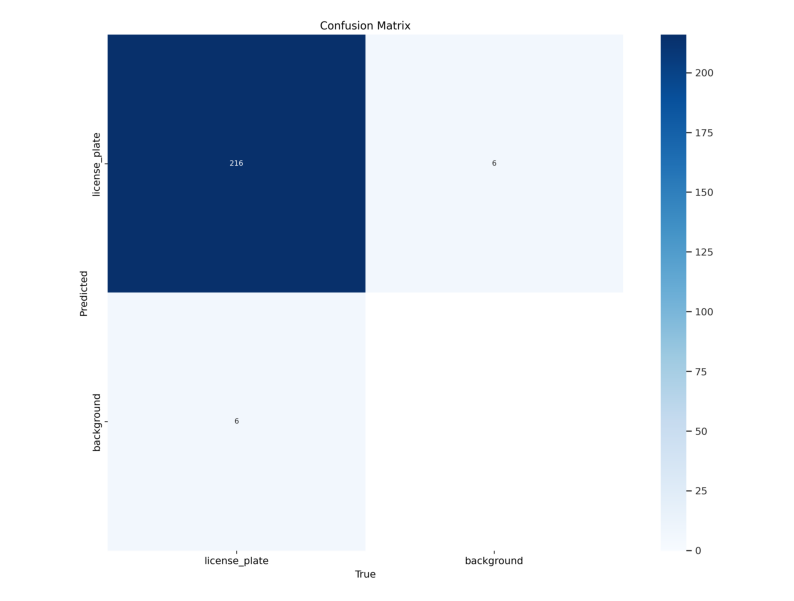

In [21]:
# Confusion Matrix
fig = plt.figure(figsize=(10, 9))
cm_img = mpimg.imread("/kaggle/working/runs/detect/val/confusion_matrix.png")
plt.imshow(cm_img)
plt.axis("off")
fig.show()

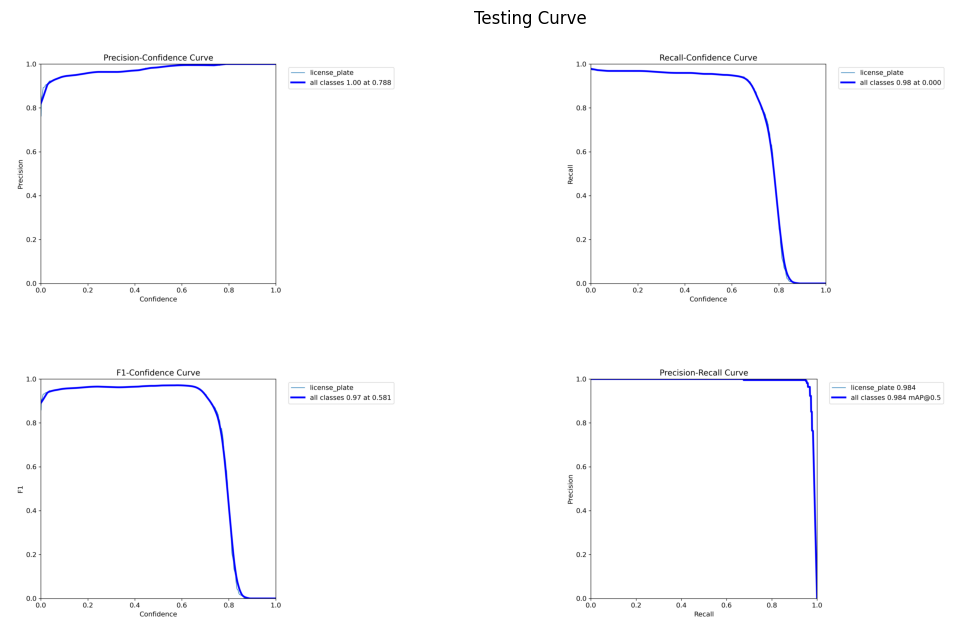

In [22]:
# Testing Curve
fig, axs = plt.subplots(2, 2, figsize=(13, 7.5))
curve_list = ["P_curve", "R_curve", "F1_curve", "PR_curve"]
for i, curve in enumerate(curve_list):
    curve_path = "/kaggle/working/runs/detect/val/{}.png".format(curve)
    curve_img = mpimg.imread(curve_path)
    axs[i//2, i%2].imshow(curve_img)
    axs[i//2, i%2].axis('off')
    
# Title
plt.suptitle("Testing Curve", x=0.55, y=0.93)

# Show
plt.show()

<div>
    <h2 id = "bbox-predictions"
        style = "background-color: #9dd6fb;
                 border-radius: 15px;
                 color: #1e3772;
                 line-height: 20px;
                 padding: 11px; 
                 font-size: 20px;
                 font-weight: bold;
                 font-family: Trebuchet MS;">3.6. Get Bounding Box Predictions
    </h2>
</div>

In [23]:
df_results = df_metadata[df_metadata["split"]=="test"].reset_index(drop=True)
df_results = df_results[["image_path", "sub", "plate_number", "x1_bbox", "y1_bbox", "x2_bbox", "y2_bbox"]]
df_results

,image_path,sub,plate_number,x1_bbox,y1_bbox,x2_bbox,y2_bbox
0,/kaggle/input/chinese-city-parking-dataset-ecc...,ccpd_fn,皖A584P4,325,462,414,493
1,/kaggle/input/chinese-city-parking-dataset-ecc...,ccpd_fn,皖AC335W,101,490,557,639
2,/kaggle/input/chinese-city-parking-dataset-ecc...,ccpd_fn,沪C41Q95,184,454,583,657
3,/kaggle/input/chinese-city-parking-dataset-ecc...,ccpd_fn,皖ACS498,272,494,364,551
4,/kaggle/input/chinese-city-parking-dataset-ecc...,ccpd_fn,皖ALY728,66,454,719,611
...,...,...,...,...,...,...,...
245,/kaggle/input/chinese-city-parking-dataset-ecc...,ccpd_blur,皖AR7592,356,445,470,485
246,/kaggle/input/chinese-city-parking-dataset-ecc...,ccpd_blur,皖AN906J,347,332,465,376
247,/kaggle/input/chinese-city-parking-dataset-ecc...,ccpd_blur,皖A187L8,256,482,508,597
248,/kaggle/input/chinese-city-parking-dataset-ecc...,ccpd_blur,皖A7U770,217,481,396,584


In [24]:
# Get Bounding Box Predictions
from ultralytics import YOLO

yolo_model = YOLO('/kaggle/working/runs/detect/train/weights/best.pt')
bbox_results = yolo_model.predict(list(df_results["image_path"]), verbose=False)
all_box_list = []
all_conf_list = []
for bbox_result in bbox_results:
    boxes = bbox_result.boxes
    box_list = []
    conf_list = []
    for box in boxes:
        box_data = box.data[0][:4]
        box_data = [int(x) for x in box_data]
        conf = round(float(box.conf), 2)
        if(conf>=0.5):
            box_list.append(box_data)
            conf_list.append(conf)
    
    all_box_list.append(box_list)
    all_conf_list.append(conf_list)

In [25]:
df_results["pred_bbox"] = all_box_list
df_results["confidence"] = all_conf_list
df_results

,image_path,sub,plate_number,x1_bbox,y1_bbox,x2_bbox,y2_bbox,pred_bbox,confidence
0,/kaggle/input/chinese-city-parking-dataset-ecc...,ccpd_fn,皖A584P4,325,462,414,493,"[[321, 460, 413, 494]]",[0.68]
1,/kaggle/input/chinese-city-parking-dataset-ecc...,ccpd_fn,皖AC335W,101,490,557,639,"[[121, 488, 540, 631], [122, 509, 449, 643], [...","[0.76, 0.75, 0.5]"
2,/kaggle/input/chinese-city-parking-dataset-ecc...,ccpd_fn,沪C41Q95,184,454,583,657,"[[183, 478, 539, 652]]",[0.81]
3,/kaggle/input/chinese-city-parking-dataset-ecc...,ccpd_fn,皖ACS498,272,494,364,551,"[[268, 493, 366, 551]]",[0.77]
4,/kaggle/input/chinese-city-parking-dataset-ecc...,ccpd_fn,皖ALY728,66,454,719,611,"[[85, 463, 720, 667]]",[0.57]
...,...,...,...,...,...,...,...,...,...
245,/kaggle/input/chinese-city-parking-dataset-ecc...,ccpd_blur,皖AR7592,356,445,470,485,"[[352, 442, 469, 484]]",[0.72]
246,/kaggle/input/chinese-city-parking-dataset-ecc...,ccpd_blur,皖AN906J,347,332,465,376,"[[339, 332, 462, 378]]",[0.75]
247,/kaggle/input/chinese-city-parking-dataset-ecc...,ccpd_blur,皖A187L8,256,482,508,597,"[[269, 483, 505, 599]]",[0.77]
248,/kaggle/input/chinese-city-parking-dataset-ecc...,ccpd_blur,皖A7U770,217,481,396,584,"[[222, 488, 384, 579]]",[0.81]


<div>
    <h2 id = "show-test-images-detection"
        style = "background-color: #9dd6fb;
                 border-radius: 15px;
                 color: #1e3772;
                 line-height: 20px;
                 padding: 11px; 
                 font-size: 20px;
                 font-weight: bold;
                 font-family: Trebuchet MS;">3.7. Show Test Images after Detection
    </h2>
</div>

/kaggle/input/chinese-city-parking-dataset-eccv/CCPD2019/ccpd_fn/0033-0_1-325&462_414&493-414&492_326&493_325&463_413&462-0_0_29_32_28_13_28-102-9.jpg


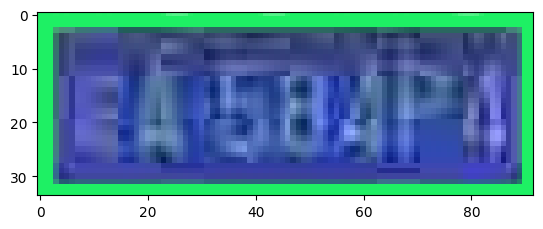

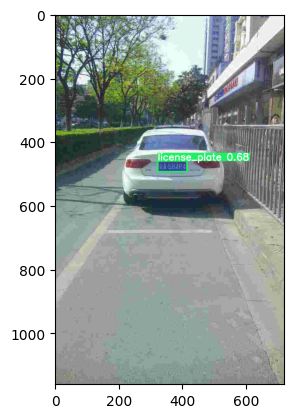

/kaggle/input/chinese-city-parking-dataset-eccv/CCPD2019/ccpd_db/0559-1_1-188&498_565&622-565&622_188&613_188&498_565&507-0_9_9_7_29_30_26-26-7.jpg


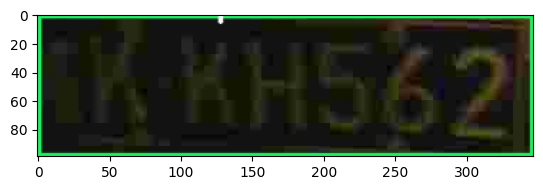

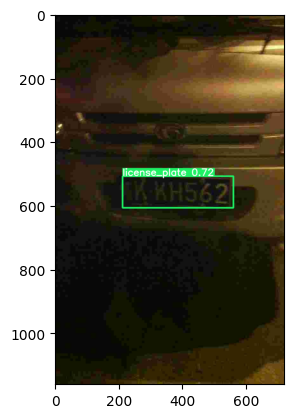

/kaggle/input/chinese-city-parking-dataset-eccv/CCPD2019/ccpd_rotate/0211-27_19-401&468_534&601-524&601_401&536_411&468_534&533-10_0_15_18_29_31_30-72-25.jpg


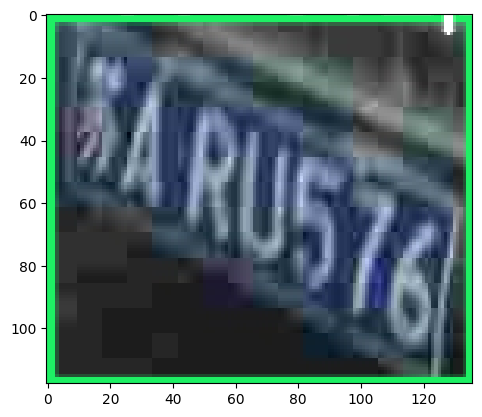

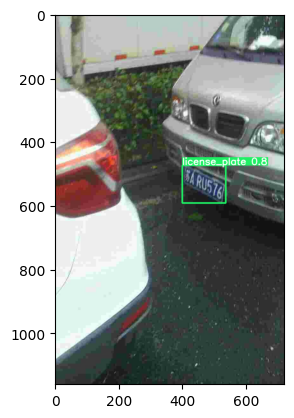

/kaggle/input/chinese-city-parking-dataset-eccv/CCPD2019/ccpd_weather/0237-0_4-162&500_401&583-401&583_167&579_162&500_396&504-10_4_27_27_19_2_24-46-9.jpg


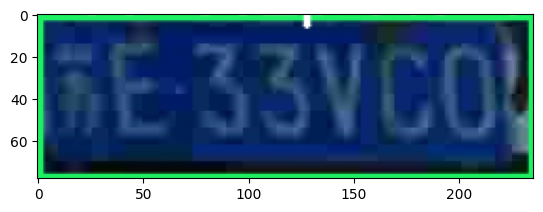

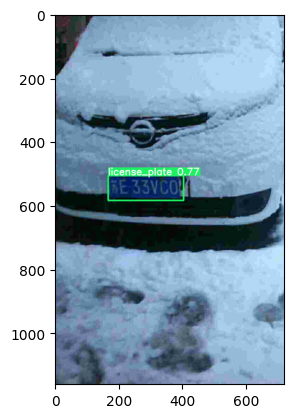

/kaggle/input/chinese-city-parking-dataset-eccv/CCPD2019/ccpd_blur/0486-0_1-206&421_539&543-536&541_206&543_209&423_539&421-0_0_28_3_32_24_30-20-3.jpg


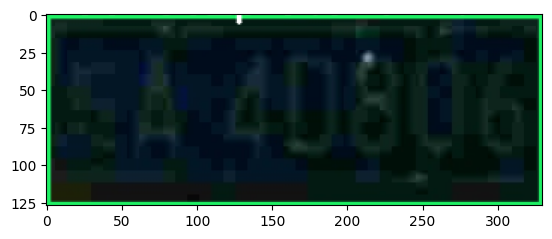

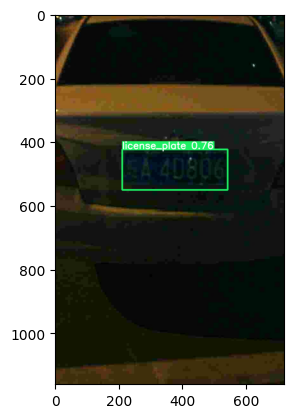

In [26]:
%matplotlib inline
from ultralytics.yolo.utils.plotting import Annotator

def show_plate_detection(idx):
    # Original Image
    ori_path = df_results["image_path"][idx]
    print(ori_path)
    ori_image = cv2.imread(ori_path)
    ori_image = cv2.cvtColor(ori_image, cv2.COLOR_BGR2RGB)

    # Annotate Box
    annotator = Annotator(ori_image)
    boxes = df_results["pred_bbox"][idx]
    confs = df_results["confidence"][idx]
    for i, box in enumerate(boxes):
        annotator.box_label(box=box, label="license_plate " + (str(confs[i])), color=(30, 240, 100))

        # Get Plate Object
        x1, y1, x2, y2 = box
        x1, y1, x2, y2 = int(x1), int(y1), int(x2), int(y2)
        roi = ori_image[y1:y2, x1:x2]
        plt.imshow(roi)
        plt.show()

    # Show Image
    frame = annotator.result()
    plt.imshow(frame)
    plt.show()

idxs = [0, 50, 100, 150, 200]
for idx in idxs:
    show_plate_detection(idx)

<div>
    <h1 id = "plate-recognition"
        style = "background-color: #9dd6fb;
                 border-radius: 15px;
                 border-left:15px #1e3772 solid;
                 color: #1e3772;
                 line-height: 26px;
                 padding: 12px; 
                 font-size: 24px;
                 font-weight: bold;
                 font-family: Trebuchet MS;">4. Plate Recognition - CnOCR
        <a class="anchor-link" id="plate-recognition" href="https://www.kaggle.com/code/harits/chinese-license-plate-recognition-yolov8-cnocr#plate-recognition">¶</a>
    </h1>
</div>

<div>
    <h2 id = "text-predictions"
        style = "background-color: #9dd6fb;
                 border-radius: 15px;
                 color: #1e3772;
                 line-height: 20px;
                 padding: 11px; 
                 font-size: 20px;
                 font-weight: bold;
                 font-family: Trebuchet MS;">4.1. Get Text Predictions
    </h2>
</div>

In [27]:
!pip install cnocr

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.5/204.5 kB 10.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 56.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 244.1/244.1 kB 25.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... - \ done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 5.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 11.7 MB/s eta 0:00:00
  Created wheel for Polygon3: filename=Polygon3-3.0.9.1-cp310-cp310-linux_x86_64.whl size=47804 sha256=ebecf4deb2d60493035949ba1174c1c21590ce4616e03dad34ab3422e57cc0b0
  Stored in directory: /root/.cache/pip/wheels/d8/b7/f6/b4e24f56a1cc9856dca98cc2fdc3915d7649b39b62f3dbca9e
Successfully built Polygon3


In [28]:
from cnocr import CnOcr

def get_text_cnocr(idx):
    ori_path = df_results["image_path"][idx]
    ori_image = cv2.imread(ori_path)
    ori_image = cv2.cvtColor(ori_image, cv2.COLOR_BGR2RGB)
    cnocr_model = CnOcr()
    text_list = []
    bboxs = df_results["pred_bbox"][idx]
    for bbox in bboxs:
        # Crop Image with Bounding Box
        crop_image = ori_image[bbox[1]:bbox[3], bbox[0]:bbox[2]]
        
        # Extract Plate Number
        text_output = cnocr_model.ocr(crop_image)
        if(len(text_output)>0):
            text = text_output[0]["text"]
            
            # Clean Text
            del_punc_list = [" ", "·", ":", "-"]
            clean_text = re.sub(r"[ ·:-]", "", text)
            clean_text = clean_text.replace("O", "0")
            clean_text = clean_text.replace("I", "1")
            clean_text = clean_text.upper()
            text_list.append(clean_text)
            
    return text_list

In [29]:
idxs = list(np.arange(0, 250))
text_results = tqdm([get_text_cnocr(idx) for idx in idxs])
text_results = [text[0] if len(text)>0 else "" for text in text_results]
df_results["pred_plate_number"] = text_results
df_results

100%|██████████| 5579/5579 [00:00<00:00, 36715.19KB/s]
2171KB [00:00, 17391.82KB/s]                          
100%|██████████| 250/250 [00:00<00:00, 397187.88it/s]


,image_path,sub,plate_number,x1_bbox,y1_bbox,x2_bbox,y2_bbox,pred_bbox,confidence,pred_plate_number
0,/kaggle/input/chinese-city-parking-dataset-ecc...,ccpd_fn,皖A584P4,325,462,414,493,"[[321, 460, 413, 494]]",[0.68],三5日年
1,/kaggle/input/chinese-city-parking-dataset-ecc...,ccpd_fn,皖AC335W,101,490,557,639,"[[121, 488, 540, 631], [122, 509, 449, 643], [...","[0.76, 0.75, 0.5]",红元西
2,/kaggle/input/chinese-city-parking-dataset-ecc...,ccpd_fn,沪C41Q95,184,454,583,657,"[[183, 478, 539, 652]]",[0.81],沙E
3,/kaggle/input/chinese-city-parking-dataset-ecc...,ccpd_fn,皖ACS498,272,494,364,551,"[[268, 493, 366, 551]]",[0.77],ACS498
4,/kaggle/input/chinese-city-parking-dataset-ecc...,ccpd_fn,皖ALY728,66,454,719,611,"[[85, 463, 720, 667]]",[0.57],宝区Y728
...,...,...,...,...,...,...,...,...,...,...
245,/kaggle/input/chinese-city-parking-dataset-ecc...,ccpd_blur,皖AR7592,356,445,470,485,"[[352, 442, 469, 484]]",[0.72],电ARTE
246,/kaggle/input/chinese-city-parking-dataset-ecc...,ccpd_blur,皖AN906J,347,332,465,376,"[[339, 332, 462, 378]]",[0.75],一A4906J
247,/kaggle/input/chinese-city-parking-dataset-ecc...,ccpd_blur,皖A187L8,256,482,508,597,"[[269, 483, 505, 599]]",[0.77],
248,/kaggle/input/chinese-city-parking-dataset-ecc...,ccpd_blur,皖A7U770,217,481,396,584,"[[222, 488, 384, 579]]",[0.81],


<div>
    <h2 id = "show-test-images-detection"
        style = "background-color: #9dd6fb;
                 border-radius: 15px;
                 color: #1e3772;
                 line-height: 20px;
                 padding: 11px; 
                 font-size: 20px;
                 font-weight: bold;
                 font-family: Trebuchet MS;">4.2. Show Test Images after Text Recognition
    </h2>
</div>

/kaggle/input/chinese-city-parking-dataset-eccv/CCPD2019/ccpd_fn/0033-0_1-325&462_414&493-414&492_326&493_325&463_413&462-0_0_29_32_28_13_28-102-9.jpg


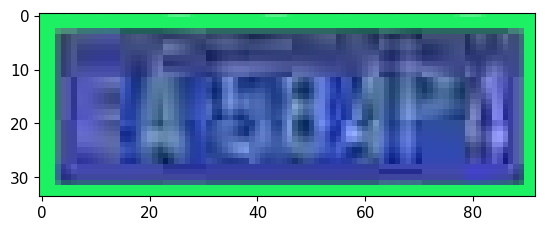

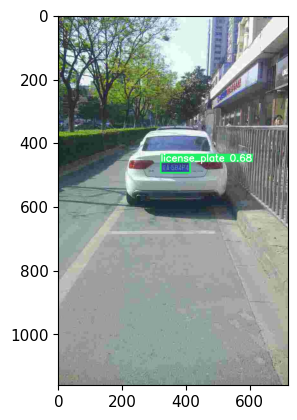

['三5日年']
/kaggle/input/chinese-city-parking-dataset-eccv/CCPD2019/ccpd_db/0559-1_1-188&498_565&622-565&622_188&613_188&498_565&507-0_9_9_7_29_30_26-26-7.jpg


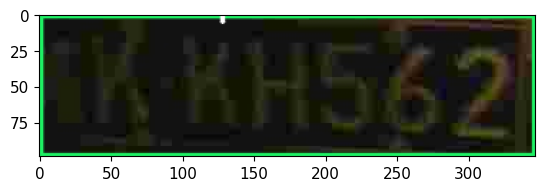

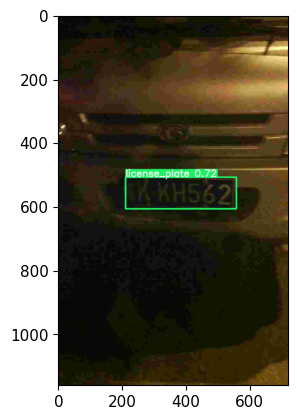

['一']
/kaggle/input/chinese-city-parking-dataset-eccv/CCPD2019/ccpd_rotate/0211-27_19-401&468_534&601-524&601_401&536_411&468_534&533-10_0_15_18_29_31_30-72-25.jpg


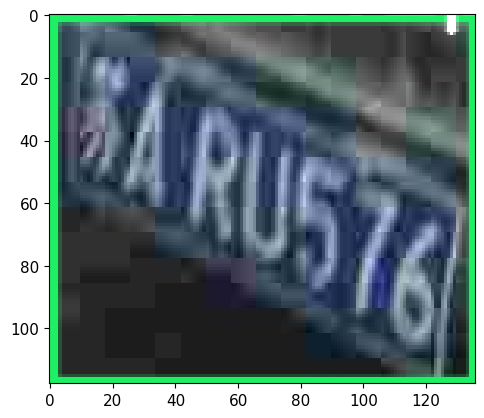

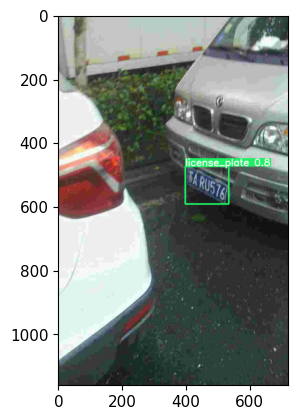

[]
/kaggle/input/chinese-city-parking-dataset-eccv/CCPD2019/ccpd_weather/0237-0_4-162&500_401&583-401&583_167&579_162&500_396&504-10_4_27_27_19_2_24-46-9.jpg


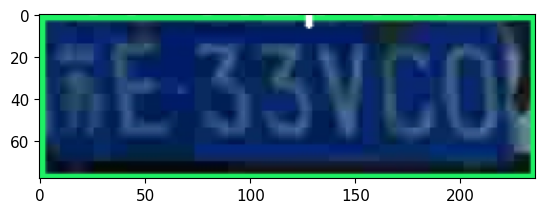

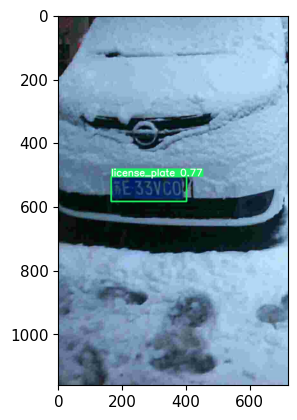

['新E33VC0']
/kaggle/input/chinese-city-parking-dataset-eccv/CCPD2019/ccpd_blur/0486-0_1-206&421_539&543-536&541_206&543_209&423_539&421-0_0_28_3_32_24_30-20-3.jpg


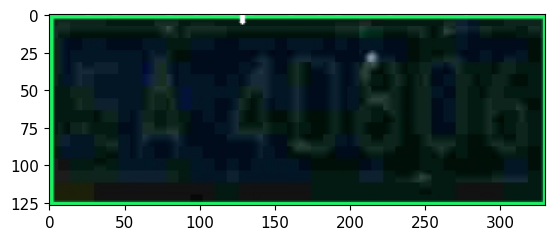

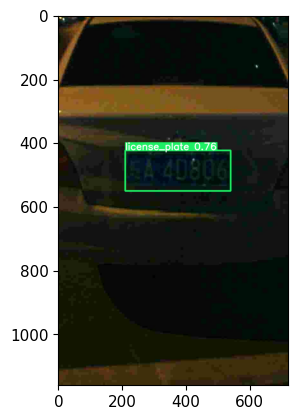

['A门8']


In [30]:
%matplotlib inline
idxs = [0, 50, 100, 150, 200]
for idx in idxs:
    show_plate_detection(idx)
    text_ocr = get_text_cnocr(idx)
    print(text_ocr)

<div>
    <h2 id = "title"
        style = "background-color: #2788f9;
                 border-radius: 9px;
                 color: #f8f8f8;
                 line-height: 50px;
                 padding: 15px 0px 15px 20px; 
                 text-align: center;
                 font-size: 28px;
                 font-weight: bold;
                 font-family: Trebuchet MS;">To be continued
    </h2>
</div>

<div class="alert alert-block alert-info" style="color: black; font-size: 15px; font-family: Trebuchet MS">
    <b>References</b>:
    <ul>
        <li>CCPD (Chinese City Parking Dataset, ECCV): <a href="https://github.com/detectRecog/CCPD"><u>https://github.com/detectRecog/CCPD</u></a></li>
        <li>Towards End-to-End License Plate Detection and Recognition: A Large Dataset and Baseline; Xu, Zhenbo and Yang, Wei and Meng, Ajin and Lu, Nanxue and Huang, Huan; Proceedings of the European Conference on Computer Vision (ECCV); 255--271; 2018</li>
        <li>Automatic Number Plate Recognition Notebook - Aslan Ahmedov: <a href="https://www.kaggle.com/code/aslanahmedov/automatic-number-plate-recognition"><u>https://www.kaggle.com/code/aslanahmedov/automatic-number-plate-recognition</u></a></li>
    </ul>
    <b>Improvements</b>:
    <ul>
        <li>Improve image quality to get better text extraction results after cropping from model detection.</li>
        <li>It can use a model that performs both plate detection and recognition simultaneously such as RPNet from main paper sources.</li>
    </ul>
</div>